In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# !PYTHONPATH=../src python ../main.py

In [3]:
# !PYTHONPATH=../src python ../src/stress_engine/monte_carlo.py

In [4]:
# !PYTHONPATH=../src python ../src/stress_engine/monte_carlo_shock.py

In [5]:
import sys
from pathlib import Path

# Setup path to include src/
src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from stress_engine.portfolio import PortfolioVaR


def run_portfolio_analysis() -> None:
    portfolios = [
        PortfolioVaR(
            name="2008 Financial Crisis - Concentrated Financials",
            tickers=["SPY", "C", "BAC", "XLF", "GS"],
            weights=[0.2, 0.2, 0.2, 0.2, 0.2],
            start_date="2007-01-01",
            end_date="2009-12-31",
            initial_capital=1_000_000,
            confidence_level=0.95,
        ),
        PortfolioVaR(
            name="2008 Financial Crisis - Multi-Asset Diverse",
            tickers=["SPY", "TLT", "GLD", "DBC"],
            weights=[0.4, 0.3, 0.2, 0.1],
            start_date="2007-01-01",
            end_date="2009-12-31",
            initial_capital=1_000_000,
            confidence_level=0.95,
        ),
    ]

    for port in portfolios:
        print("\n==================================================")
        print(f"Running Analysis for: {port.name}")
        print(f"Time Horizon: {port.start_date} to {port.end_date}")
        print("==================================================")

        metrics = port.run_analysis()

        print(f"Confidence Level: {port.confidence_level * 100}%")
        print(f"  - Historical VaR (%):        {metrics['hist_pct']:.4f}")
        print(
            f"  - Historical VaR ($):        ${abs(float(metrics['hist_dollar'])):,.2f}"
        )
        print(f"  - Parametric (Normal) VaR (%): {metrics['param_pct']:.4f}")
        print(
            f"  - Parametric (Normal) VaR ($): ${abs(float(metrics['param_dollar'])):,.2f}"
        )


run_portfolio_analysis()


Running Analysis for: 2008 Financial Crisis - Concentrated Financials
Time Horizon: 2007-01-01 to 2009-12-31
Confidence Level: 95.0%
  - Historical VaR (%):        -0.0554
  - Historical VaR ($):        $55,370.41
  - Parametric (Normal) VaR (%): 0.0647
  - Parametric (Normal) VaR ($): $64,682.79

Running Analysis for: 2008 Financial Crisis - Multi-Asset Diverse
Time Horizon: 2007-01-01 to 2009-12-31
Confidence Level: 95.0%
  - Historical VaR (%):        -0.0163
  - Historical VaR ($):        $16,342.82
  - Parametric (Normal) VaR (%): 0.0187
  - Parametric (Normal) VaR ($): $18,654.42


In [6]:
# monte_carlo.py

import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Setup path to include src/
src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from stress_engine.monte_carlo import generate_parameter_grid, run_extended_monte_carlo


def run_standard_mc_pipeline() -> pd.DataFrame:
    grid = generate_parameter_grid()
    ledger: list[dict[str, float | str]] = []

    print("Executing standard standalone Monte Carlo stress tests...")
    for inst_name, profile in grid.items():
        prob, max_dds = run_extended_monte_carlo(profile, n_paths=2000, n_days=90)
        ledger.append(
            {
                "Institution": inst_name,
                "Annual_Vol": profile["annual_vol"],
                "Tail_DF": profile["t_df"],
                "GJR_Gamma": profile["gjr_gamma"],
                "Distress_Probability": prob,
                "Mean_Max_DD": float(np.mean(max_dds)),
                "P95_Max_DD": float(np.percentile(max_dds, 5)),
            }
        )

    df_out = pd.DataFrame(ledger)
    output_dir = Path("../data/raw")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / "synthetic_monte_carlo_results.parquet"

    df_out.to_parquet(output_file, index=False)
    print(f"Standard simulation results saved to: {output_file}")
    return df_out


df_standard_results = run_standard_mc_pipeline()
df_standard_results.head()

Executing standard standalone Monte Carlo stress tests...
Standard simulation results saved to: ../data/raw/synthetic_monte_carlo_results.parquet


,Institution,Annual_Vol,Tail_DF,GJR_Gamma,Distress_Probability,Mean_Max_DD,P95_Max_DD
0,Vol-Low_Tail-Fat_Asym-Low,0.1,3.5,0.01,0.0,-0.004025,-0.007973
1,Vol-Low_Tail-Fat_Asym-Norm,0.1,3.5,0.05,0.0,-0.004082,-0.007901
2,Vol-Low_Tail-Fat_Asym-High,0.1,3.5,0.15,0.0,-0.004135,-0.008013
3,Vol-Low_Tail-Norm_Asym-Low,0.1,8.0,0.01,0.0,-0.004203,-0.008094
4,Vol-Low_Tail-Norm_Asym-Norm,0.1,8.0,0.05,0.0,-0.004286,-0.008004


In [7]:
# monte_carlo_shock.py

import sys
from pathlib import Path

import pandas as pd

# Setup path to include src/
src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from stress_engine.monte_carlo_shock import (
    generate_parameter_grid,
    run_shock_monte_carlo,
)


def run_shock_mc_pipeline() -> pd.DataFrame:
    grid = generate_parameter_grid()
    ledger: list[dict[str, float | str]] = []

    print("Executing Shock-Enabled Monte Carlo Stress Tests...")
    for inst_name, profile in grid.items():
        prob, max_dds = run_shock_monte_carlo(profile, n_paths=2000, n_days=90)
        ledger.append(
            {
                "Institution": inst_name,
                "Annual_Vol": profile["annual_vol"],
                "Tail_DF": profile["t_df"],
                "GJR_Gamma": profile["gjr_gamma"],
                "Distress_Probability": prob,
                "Mean_Max_DD": float(np.mean(max_dds)),
                "P95_Max_DD": float(np.percentile(max_dds, 5)),
            }
        )

    df_out = pd.DataFrame(ledger)
    output_dir = Path("../data/raw")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / "synthetic_monte_carlo_shock_results.parquet"

    df_out.to_parquet(output_file, index=False)
    print(f"Shock simulation results saved to: {output_file}")
    return df_out


df_shock_results = run_shock_mc_pipeline()
df_shock_results.sort_values(by="Distress_Probability", ascending=False).head(10)

Executing Shock-Enabled Monte Carlo Stress Tests...
Shock simulation results saved to: ../data/raw/synthetic_monte_carlo_shock_results.parquet


,Institution,Annual_Vol,Tail_DF,GJR_Gamma,Distress_Probability,Mean_Max_DD,P95_Max_DD
0,Vol-Low_Tail-Fat_Asym-Low,0.10,3.5,0.01,1.0,-0.426186,-0.428446
1,Vol-Low_Tail-Fat_Asym-Norm,0.10,3.5,0.05,1.0,-0.569834,-0.571663
2,Vol-Low_Tail-Fat_Asym-High,0.10,3.5,0.15,1.0,-0.790610,-0.791528
5,Vol-Low_Tail-Norm_Asym-High,0.10,8.0,0.15,1.0,-0.496575,-0.498833
10,Vol-Norm_Tail-Fat_Asym-Norm,0.20,3.5,0.05,1.0,-0.571394,-0.575049
9,Vol-Norm_Tail-Fat_Asym-Low,0.20,3.5,0.01,1.0,-0.428244,-0.432762
20,Vol-High_Tail-Fat_Asym-High,0.35,3.5,0.15,1.0,-0.792465,-0.795433
19,Vol-High_Tail-Fat_Asym-Norm,0.35,3.5,0.05,1.0,-0.573706,-0.579843
18,Vol-High_Tail-Fat_Asym-Low,0.35,3.5,0.01,1.0,-0.431195,-0.439264
14,Vol-Norm_Tail-Norm_Asym-High,0.20,8.0,0.15,1.0,-0.498400,-0.502727


In [8]:
# shock_day = 30
# if n_days > shock_day:
#     tail_multiplier = (
#         3.0 / df
#     )  # Heavier tails (e.g., df=3.5) amplify the shock impact
#     shock_magnitude = -0.28 * (1.0 + gamma * 10.0) * tail_multiplier
#     z[:, shock_day] = shock_magnitude / (daily_vol * np.sqrt(dt))

# Institution	Annual_Vol	Tail_DF	GJR_Gamma	Distress_Probability	Mean_Max_DD	P95_Max_DD
# 0	Vol-Low_Tail-Fat_Asym-Low	0.1	3.5	0.01	0.0	-0.148706	-0.152296
# 1	Vol-Low_Tail-Fat_Asym-Norm	0.1	3.5	0.05	0.0	-0.173891	-0.177274
# 2	Vol-Low_Tail-Fat_Asym-High	0.1	3.5	0.15	0.0	-0.233642	-0.236819
# 3	Vol-Low_Tail-Norm_Asym-Low	0.1	8.0	0.01	0.0	-0.148900	-0.152399
# 4	Vol-Low_Tail-Norm_Asym-Norm	0.1	8.0	0.05	0.0	-0.173972	-0.177206
# 5	Vol-Low_Tail-Norm_Asym-High	0.1	8.0	0.15	0.0	-0.233699	-0.236963
# 6	Vol-Low_Tail-Thin_Asym-Low	0.1	30.0	0.01	0.0	-0.148828	-0.152374
# 7	Vol-Low_Tail-Thin_Asym-Norm	0.1	30.0	0.05	0.0	-0.174063	-0.177636
# 8	Vol-Low_Tail-Thin_Asym-High	0.1	30.0	0.15	0.0	-0.233741	-0.236798
# 9	Vol-Norm_Tail-Fat_Asym-Low	0.2	3.5	0.01	0.0	-0.151696	-0.158948

# Mean_man_DD has spiked, 24% - 15% shock simulation compared to 1.5% - 0.4% non-shock simulation. This is a significant increase in the probability of distress, indicating that the shock scenario has a substantial impact on the risk profile of the institutions being analyzed. Still below the 40% threshold for concern, but the increase is notable and warrants further investigation into the specific factors contributing to this heightened risk.

In [9]:
# tail_multiplier = 4.0 / df
# shock_magnitude = -0.42 * (1.0 + gamma * 15.0) * tail_multiplier
# z[:, shock_day] = shock_magnitude / (daily_vol * np.sqrt(dt))

# daily_rets = -0.5 * (daily_vol**2) * dt + daily_vol * np.sqrt(dt) * z
# log_rets = np.hstack([np.zeros((n_paths, 1)), np.cumsum(daily_rets, axis=1)])
# price_paths = initial_price * np.exp(log_rets)

# rolling_max = np.maximum.accumulate(price_paths, axis=1)
# drawdowns = (price_paths - rolling_max) / rolling_max
# max_drawdowns = np.min(drawdowns, axis=1)

# breach_count = np.sum(max_drawdowns <= distress_threshold)
# return float(breach_count / n_paths), max_drawdowns

# 	Institution	Annual_Vol	Tail_DF	GJR_Gamma	Distress_Probability	Mean_Max_DD	P95_Max_DD
# 0	Vol-Low_Tail-Fat_Asym-Low	0.10	3.5	0.01	1.0	-0.426214	-0.428532
# 1	Vol-Low_Tail-Fat_Asym-Norm	0.10	3.5	0.05	1.0	-0.569853	-0.571680
# 2	Vol-Low_Tail-Fat_Asym-High	0.10	3.5	0.15	1.0	-0.790603	-0.791478
# 5	Vol-Low_Tail-Norm_Asym-High	0.10	8.0	0.15	1.0	-0.496482	-0.498551
# 10	Vol-Norm_Tail-Fat_Asym-Norm	0.20	3.5	0.05	1.0	-0.571354	-0.574962
# 9	Vol-Norm_Tail-Fat_Asym-Low	0.20	3.5	0.01	1.0	-0.428318	-0.433393
# 20	Vol-High_Tail-Fat_Asym-High	0.35	3.5	0.15	1.0	-0.792423	-0.795576
# 19	Vol-High_Tail-Fat_Asym-Norm	0.35	3.5	0.05	1.0	-0.573506	-0.579551
# 18	Vol-High_Tail-Fat_Asym-Low	0.35	3.5	0.01	1.0	-0.431308	-0.439693
# 14	Vol-Norm_Tail-Norm_Asym-High	0.20	8.0	0.15	1.0	-0.498433	-0.502559

Compiling path-wise maximum drawdowns across 3x3x3 grid for visualization...
Visualization successfully saved to '../monte_carlo_drawdown_distributions.png'


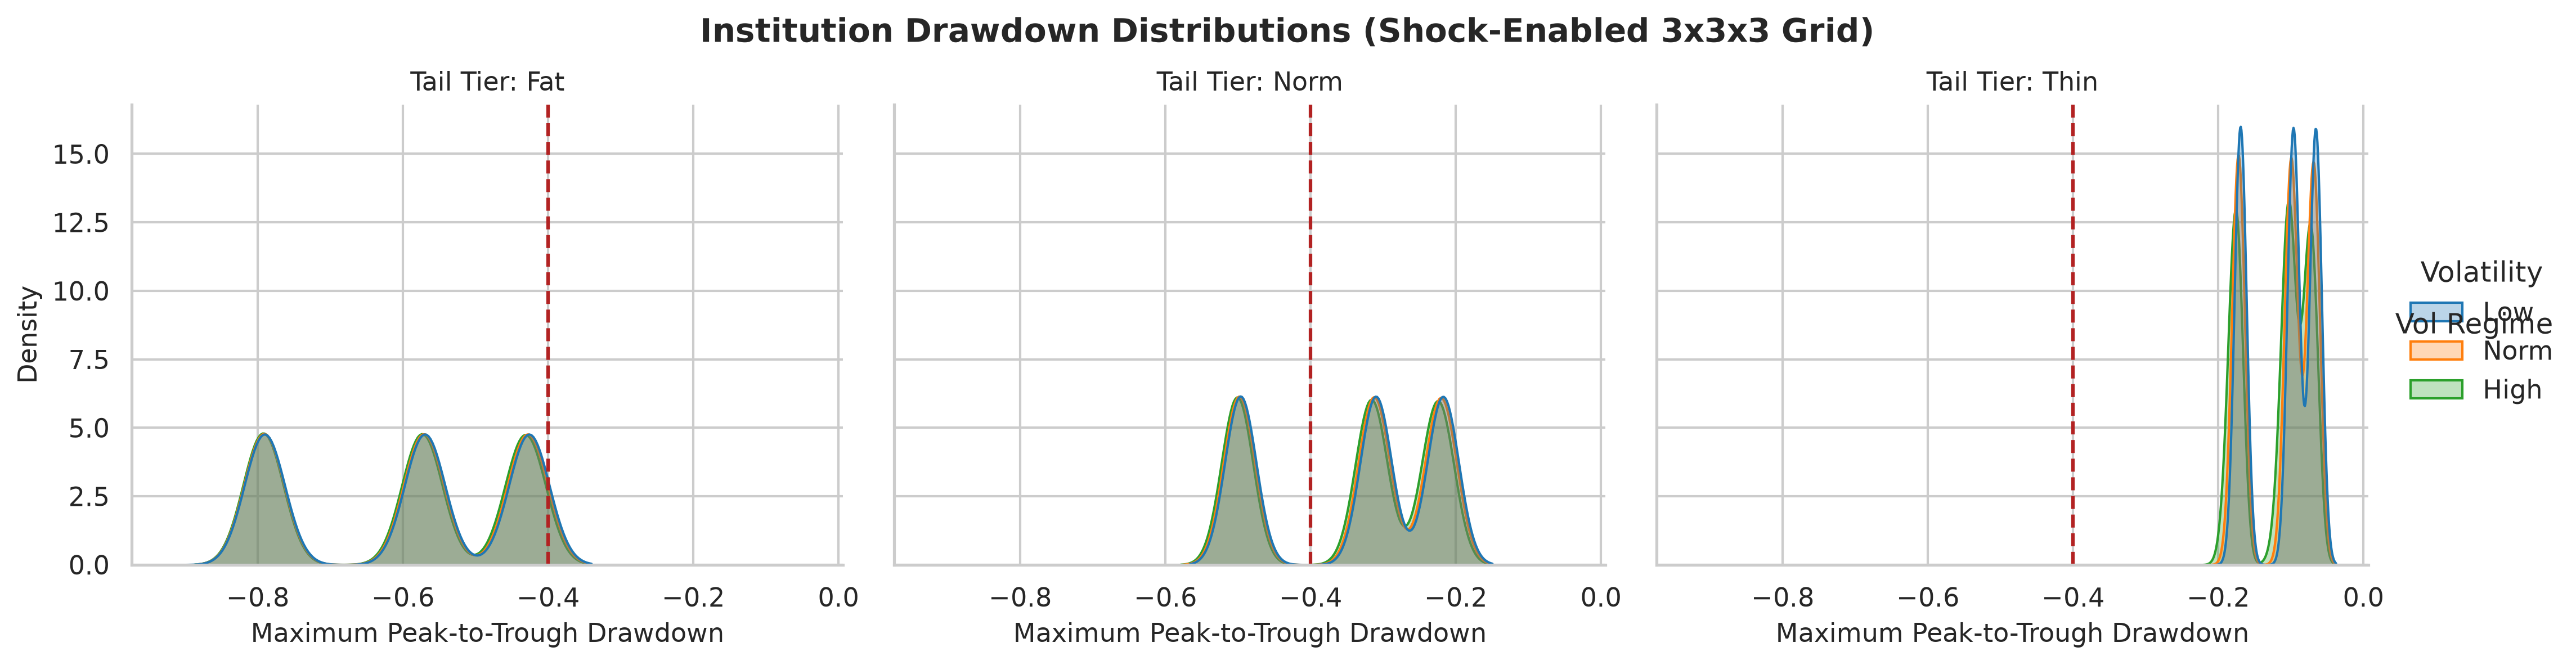

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
    }
)


def generate_drawdown_plot() -> None:
    grid = generate_parameter_grid()
    records: list[dict[str, float | str]] = []

    print(
        "Compiling path-wise maximum drawdowns across 3x3x3 grid for"
        " visualization..."
    )
    for _, profile in grid.items():
        # Run shock engine to gather distribution arrays
        _, max_drawdowns = run_shock_monte_carlo(profile, n_paths=1500, n_days=90)
        for dd in max_drawdowns:
            records.append(
                {
                    "Max_Drawdown": dd,
                    "Volatility": profile["Vol_Tier"],
                    "Tail_Thickness": profile["Tail_Tier"],
                    "Asymmetry": profile["Asym_Tier"],
                }
            )

    df_viz = pd.DataFrame(records)

    # Plot distribution grids via Seaborn Displot
    g = sns.displot(
        df_viz,
        x="Max_Drawdown",
        hue="Volatility",
        col="Tail_Thickness",
        kind="kde",
        fill=True,
        common_norm=False,
        alpha=0.3,
        palette="tab10",
        height=4,
        aspect=1.1,
    )

    # Highlight the -40% distress threshold line on all subplots
    for ax in g.axes.flat:
        ax.axvline(
            x=-0.40,
            color="firebrick",
            linestyle="--",
            linewidth=1.5,
            label="40% Distress Threshold",
        )
        ax.set_xlabel("Maximum Peak-to-Trough Drawdown")
        ax.set_ylabel("Density")

    g.set_titles(col_template="Tail Tier: {col_name}")
    g.add_legend(title="Vol Regime")
    plt.subplots_adjust(top=0.85)
    g.fig.suptitle(
        "Institution Drawdown Distributions (Shock-Enabled 3x3x3 Grid)",
        fontsize=14,
        fontweight="bold",
    )

    output_path = "../monte_carlo_drawdown_distributions.png"
    plt.savefig(output_path, bbox_inches="tight")
    print(f"Visualization successfully saved to '{output_path}'")
    plt.show()


generate_drawdown_plot()

Extracting path distributions for all 27 individual institution profiles...
27-grid visualization successfully saved to '../monte_carlo_27_grid_distributions.png'


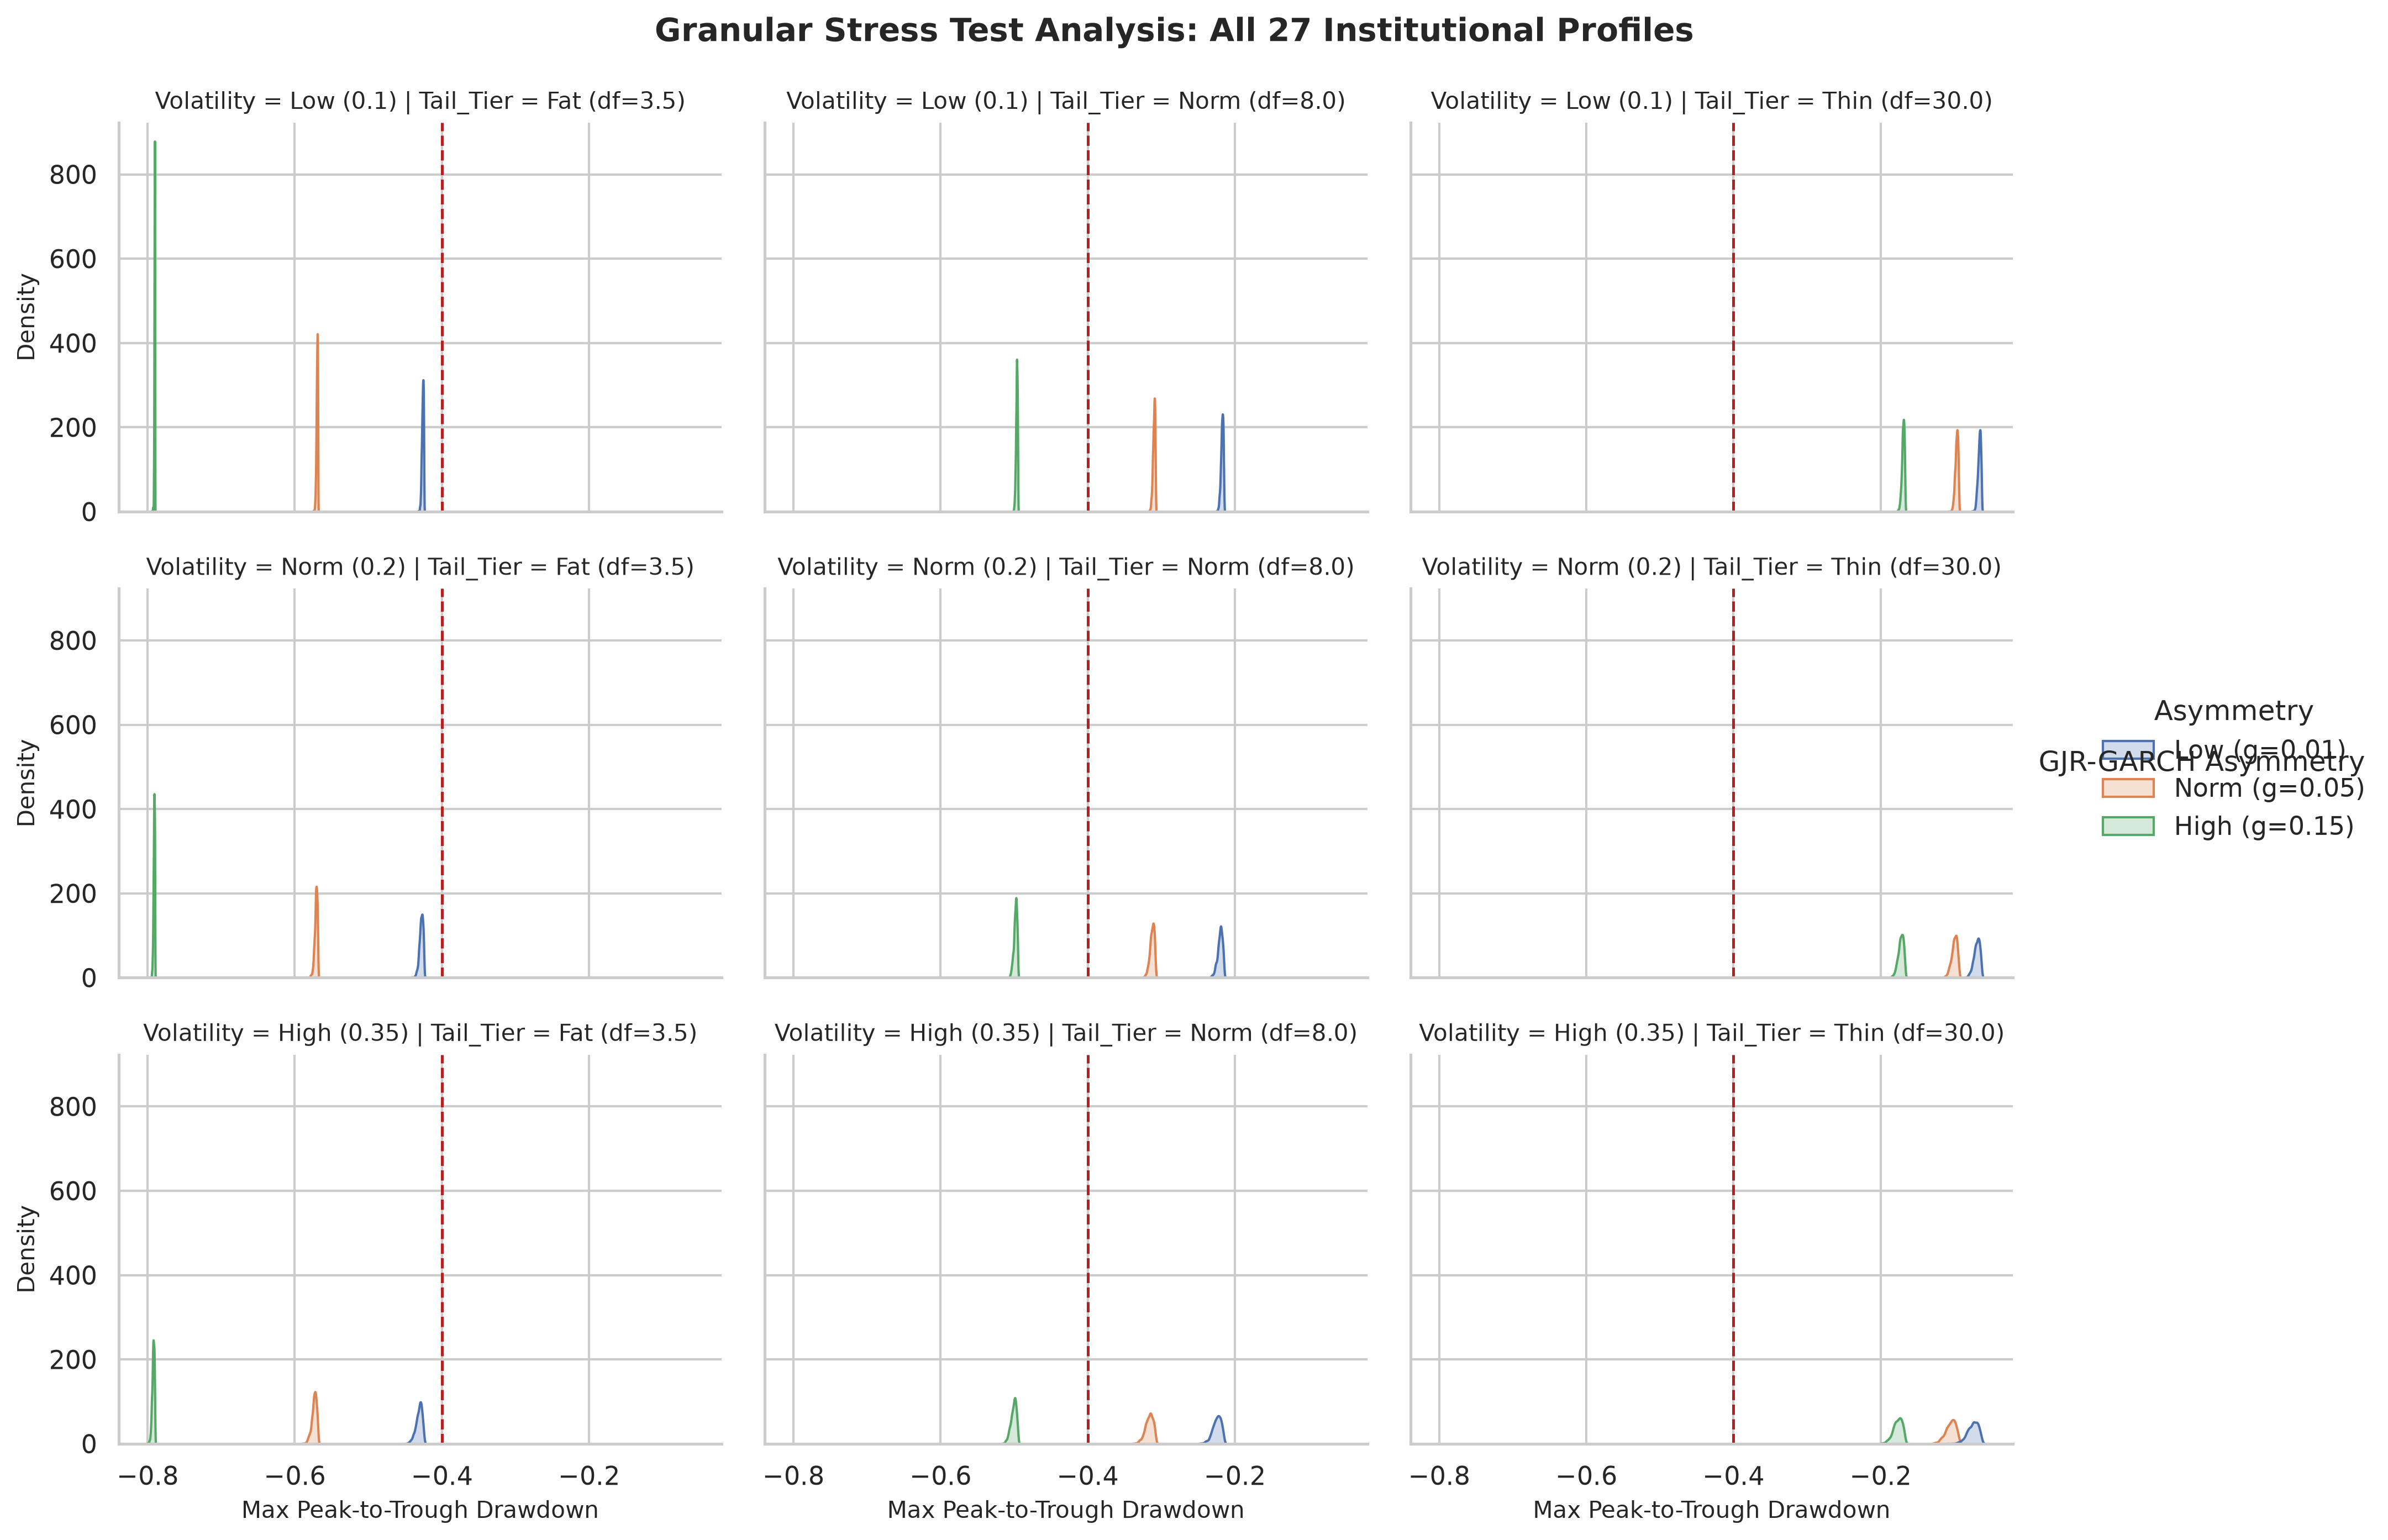

In [11]:
# individual graphs

import matplotlib.pyplot as plt
import seaborn as sns

# Set publication-grade styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
    }
)


def generate_27_grid_plot() -> None:
    grid = generate_parameter_grid()
    records: list[dict[str, float | str]] = []

    print(
        "Extracting path distributions for all 27 individual institution" " profiles..."
    )
    for inst_name, profile in grid.items():
        _, max_drawdowns = run_shock_monte_carlo(profile, n_paths=1500, n_days=90)
        for dd in max_drawdowns:
            records.append(
                {
                    "Max_Drawdown": dd,
                    "Institution": inst_name,
                    "Volatility": f"{profile['Vol_Tier']} ({profile['annual_vol']})",
                    "Tail_Tier": f"{profile['Tail_Tier']} (df={profile['t_df']})",
                    "Asymmetry": (f"{profile['Asym_Tier']} (g={profile['gjr_gamma']})"),
                }
            )

    df_viz = pd.DataFrame(records)

    # Create a FacetGrid mapping Volatility (rows) vs Tail Thickness (cols), colored by Asymmetry
    g = sns.displot(
        df_viz,
        x="Max_Drawdown",
        hue="Asymmetry",
        col="Tail_Tier",
        row="Volatility",
        kind="kde",
        fill=True,
        common_norm=False,
        alpha=0.25,
        palette="deep",
        height=3.0,
        aspect=1.2,
    )

    # Highlight the -40% distress threshold across every single subplot
    for ax in g.axes.flat:
        ax.axvline(
            x=-0.40,
            color="firebrick",
            linestyle="--",
            linewidth=1.2,
            label="40% Distress Threshold",
        )
        ax.set_xlabel("Max Peak-to-Trough Drawdown")
        ax.set_ylabel("Density")

    g.add_legend(title="GJR-GARCH Asymmetry")
    g.fig.suptitle(
        "Granular Stress Test Analysis: All 27 Institutional Profiles",
        y=1.03,
        fontsize=14,
        fontweight="bold",
    )

    output_path = "../monte_carlo_27_grid_distributions.png"
    plt.savefig(output_path)
    print(f"27-grid visualization successfully saved to '{output_path}'")
    plt.show()


generate_27_grid_plot()

Comparison chart successfully saved to '../historical_vs_stress_comparison.png'


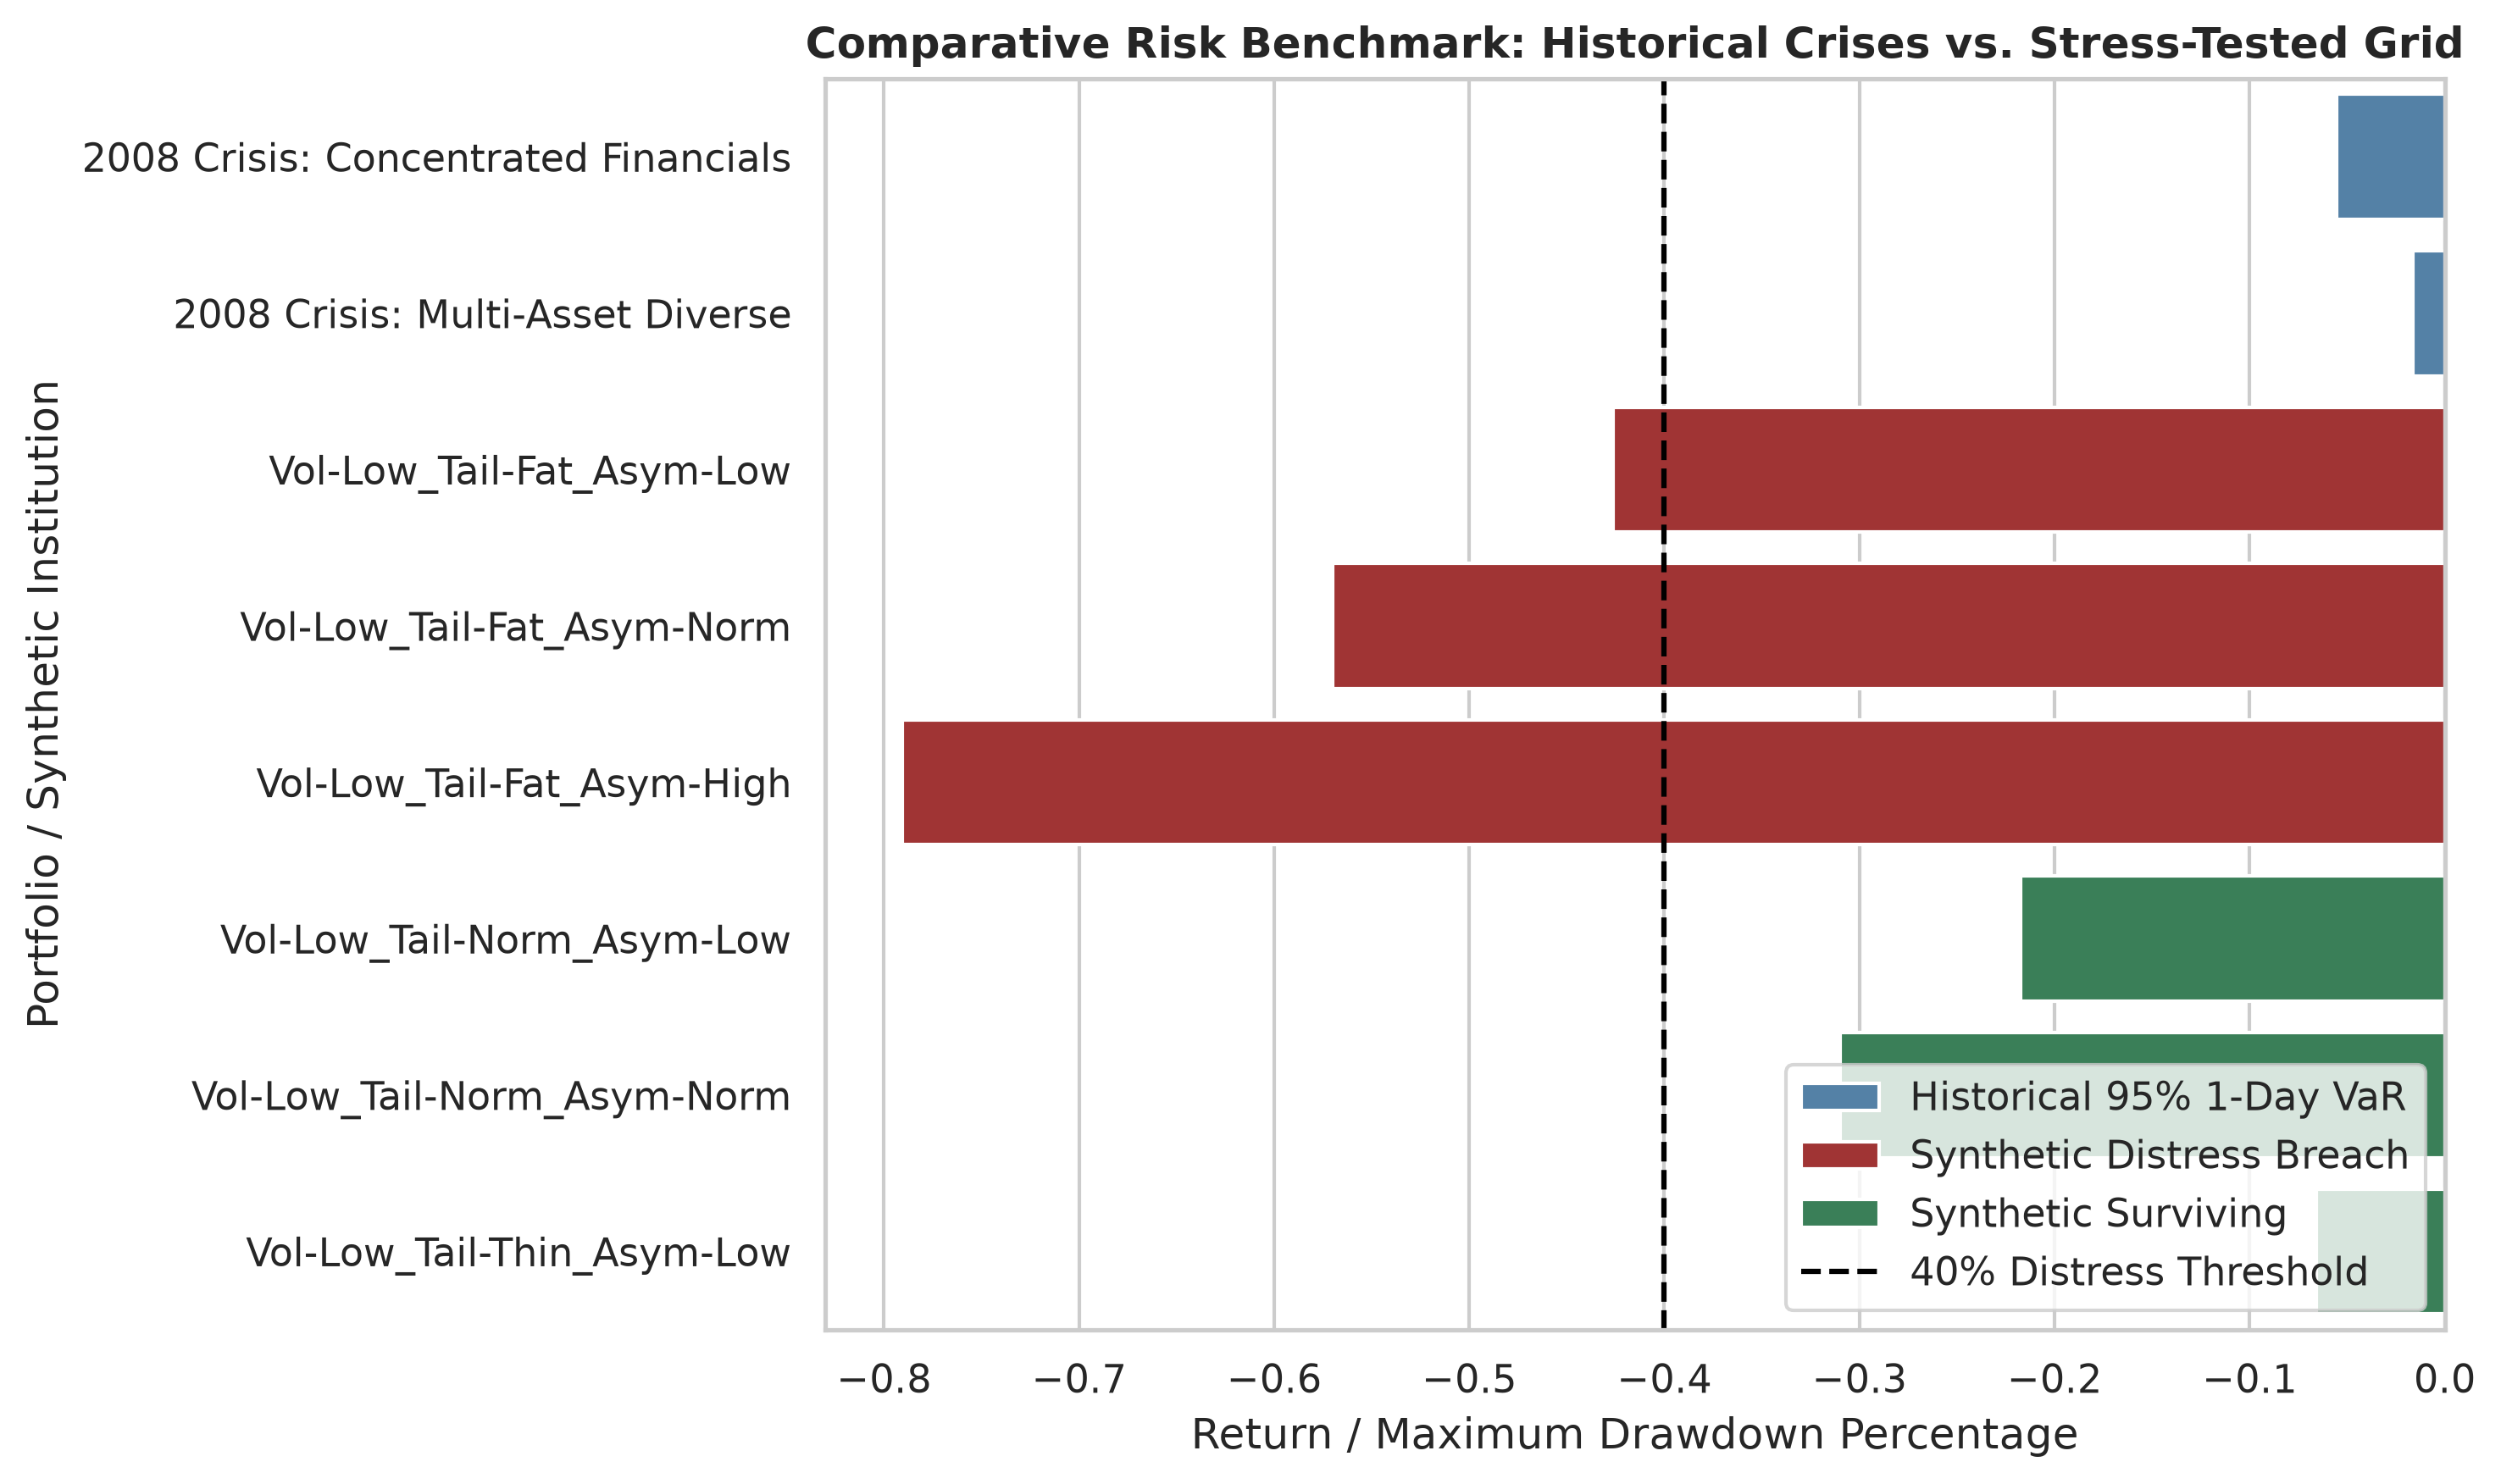

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")


def plot_historical_vs_stress_comparison() -> None:
    # Gather data from your historical portfolio run and synthetic grid
    hist_data = [
        {
            "Entity": "2008 Crisis: Concentrated Financials",
            "Metric_Value": -0.0554,
            "Type": "Historical 95% 1-Day VaR",
        },
        {
            "Entity": "2008 Crisis: Multi-Asset Diverse",
            "Metric_Value": -0.0163,
            "Type": "Historical 95% 1-Day VaR",
        },
    ]

    # Load your latest shock results parquet to pull sample mean max drawdowns
    df_shock = pd.read_parquet(
        "../data/raw/synthetic_monte_carlo_shock_results.parquet"
    )

    # Pick representative breaching and non-breaching institutions
    sample_insts = df_shock.nlargest(3, "Distress_Probability").to_dict(
        "records"
    ) + df_shock.nsmallest(3, "Distress_Probability").to_dict("records")

    for row in sample_insts:
        hist_data.append(
            {
                "Entity": row["Institution"],
                "Metric_Value": row["Mean_Max_DD"],
                "Type": (
                    "Synthetic Distress Breach"
                    if row["Distress_Probability"] > 0
                    else "Synthetic Surviving"
                ),
            }
        )

    df_plot = pd.DataFrame(hist_data)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=df_plot,
        x="Metric_Value",
        y="Entity",
        hue="Type",
        dodge=False,
        palette={
            "Historical 95% 1-Day VaR": "steelblue",
            "Synthetic Distress Breach": "firebrick",
            "Synthetic Surviving": "seagreen",
        },
    )

    ax.axvline(
        x=-0.40,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="40% Distress Threshold",
    )
    ax.set_xlabel("Return / Maximum Drawdown Percentage")
    ax.set_ylabel("Portfolio / Synthetic Institution")
    plt.title(
        "Comparative Risk Benchmark: Historical Crises vs. Stress-Tested Grid",
        fontsize=12,
        fontweight="bold",
    )
    plt.legend(loc="lower right")
    plt.tight_layout()

    output_path = "../historical_vs_stress_comparison.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Comparison chart successfully saved to '{output_path}'")
    plt.show()


plot_historical_vs_stress_comparison()

Apples-to-apples comparison chart successfully saved to '../historical_90d_vs_stress_comparison.png'


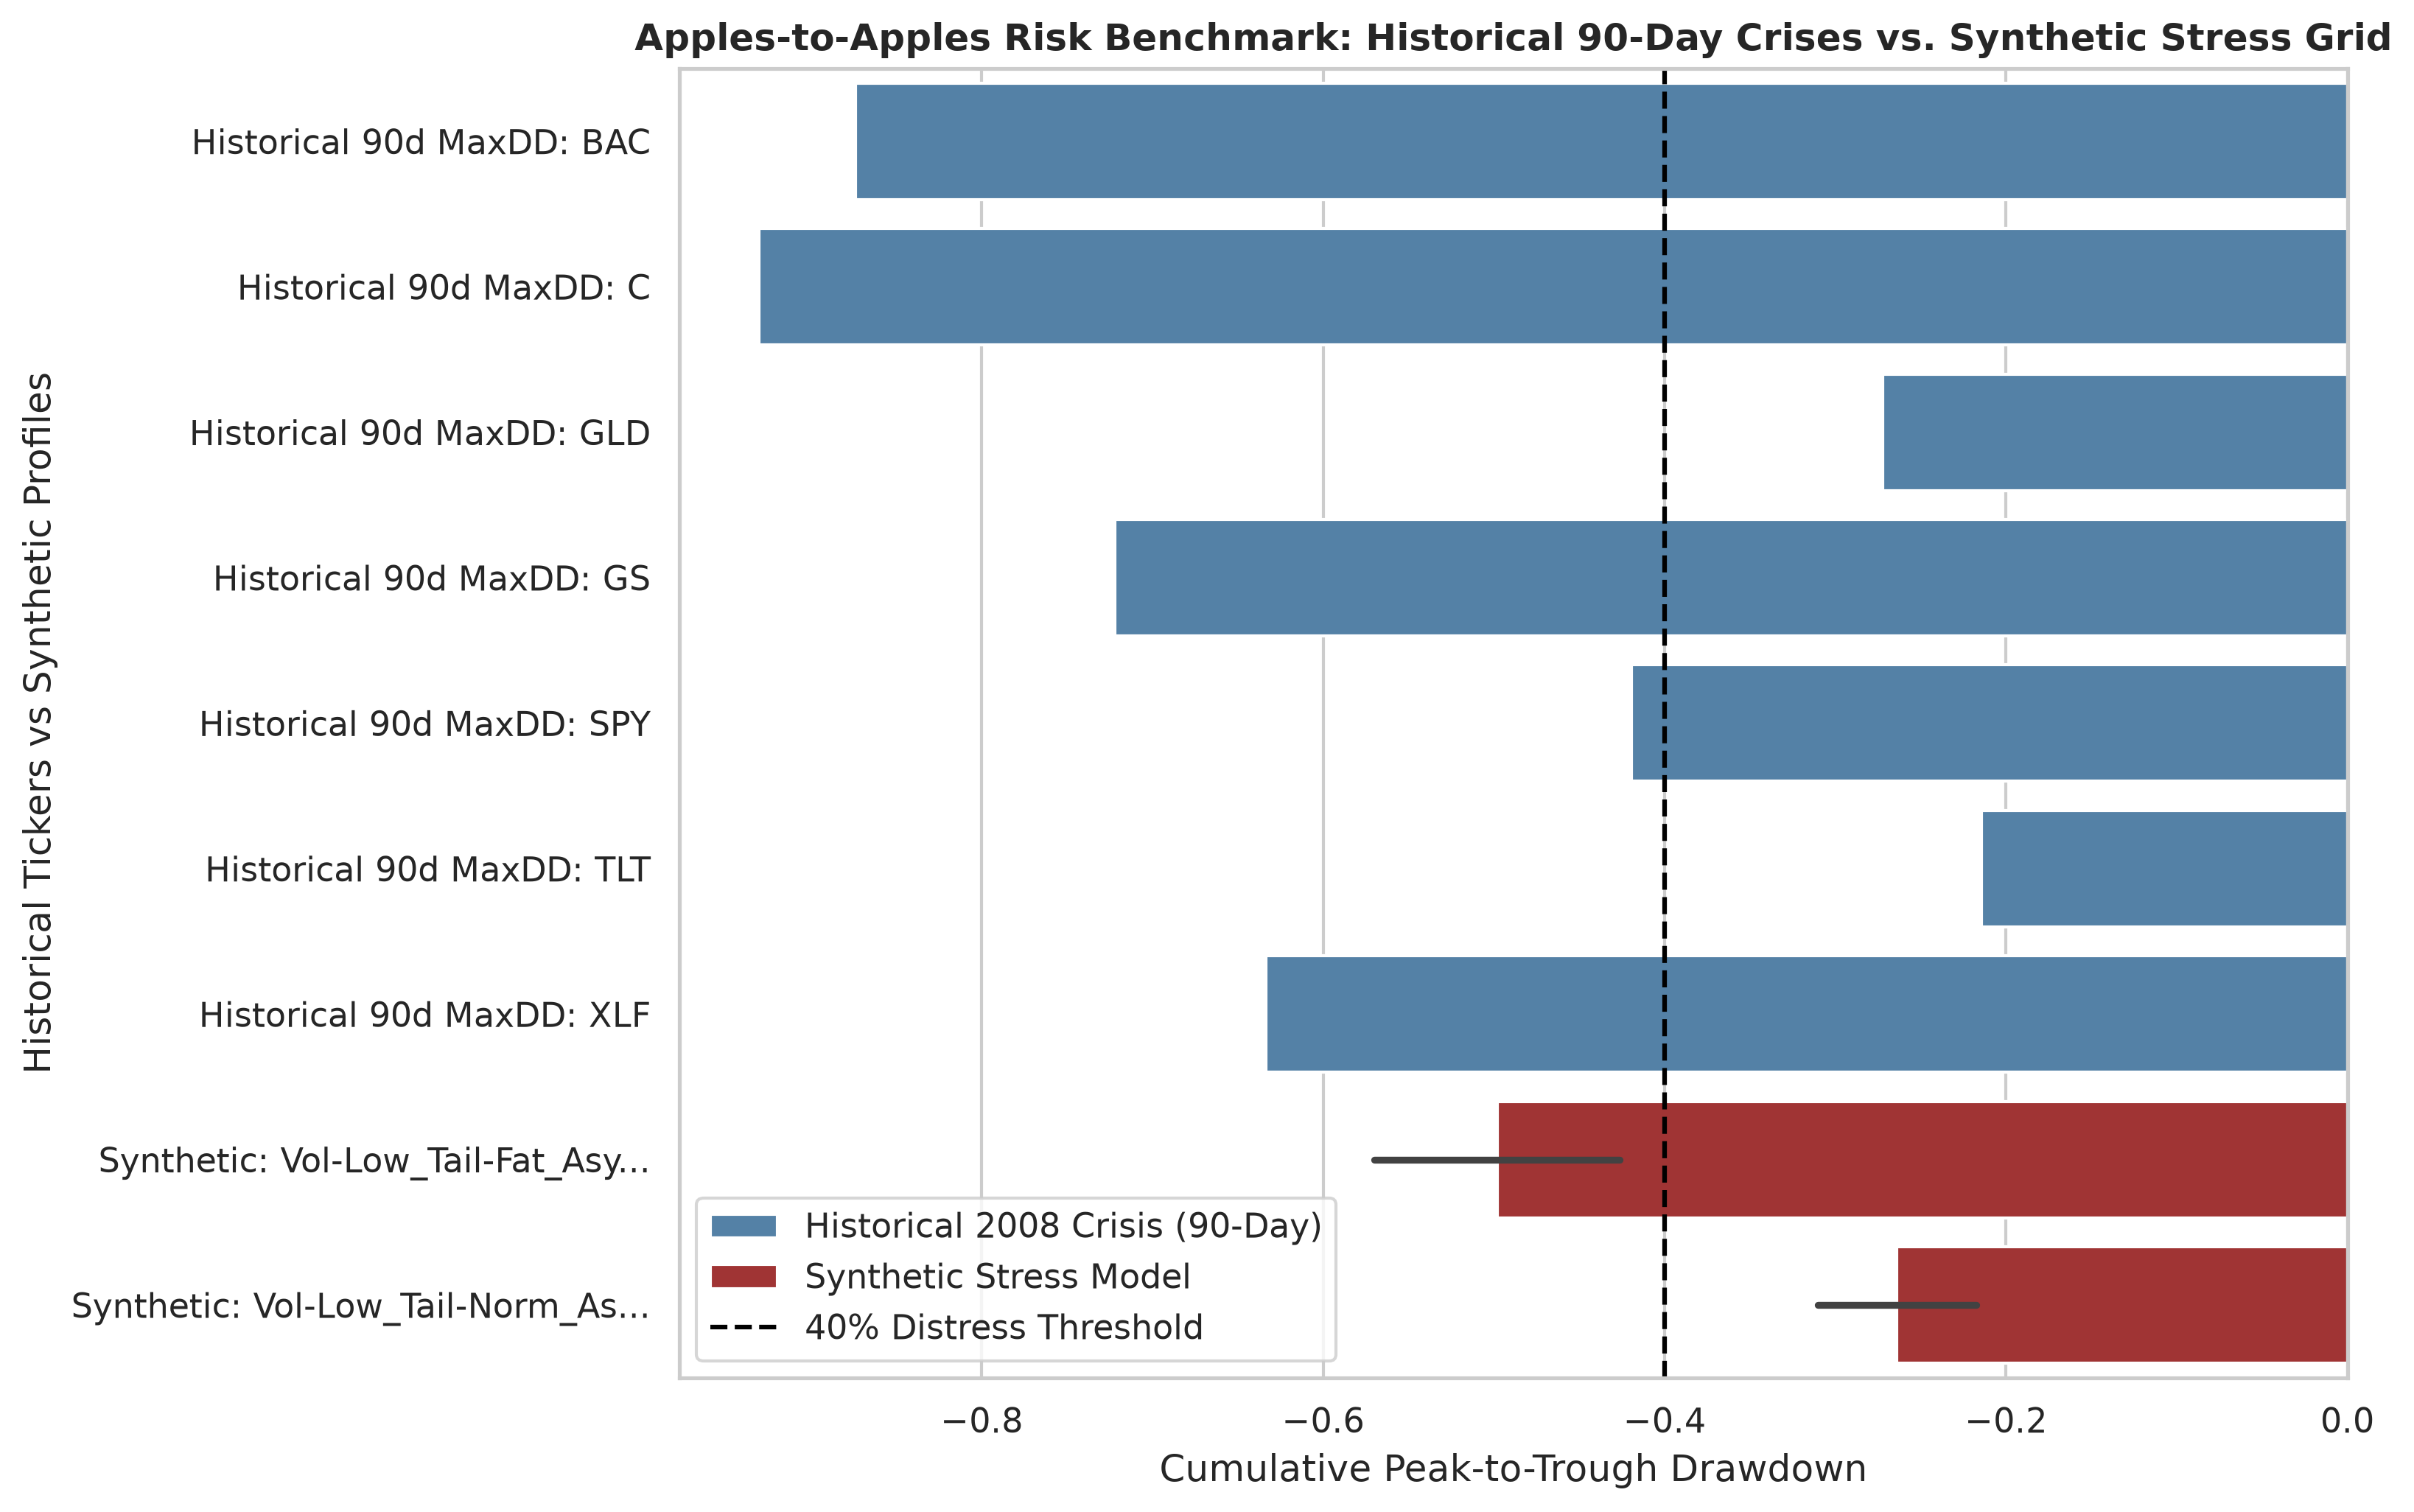

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yfinance as yf

sns.set_theme(style="whitegrid", palette="muted")


def plot_historical_rolling_drawdowns() -> None:
    # Define tickers representing concentrated financials vs diverse assets
    tickers = ["C", "BAC", "XLF", "GS", "SPY", "TLT", "GLD"]

    print("Downloading historical 2007-2009 data for rolling drawdown comparison...")
    df_prices = yf.download(
        tickers, start="2007-01-01", end="2009-12-31", progress=False
    )["Close"]

    if isinstance(df_prices.columns, pd.MultiIndex):
        df_prices = df_prices.droplevel(0, axis=1)

    # Calculate rolling 90-day max drawdowns for each historical asset
    rolling_max = df_prices.rolling(window=90, min_periods=1).max()
    drawdowns = (df_prices - rolling_max) / rolling_max
    max_dd_historical = drawdowns.min()

    hist_records = []
    for ticker, max_dd in max_dd_historical.items():
        hist_records.append(
            {
                "Entity": f"Historical 90d MaxDD: {ticker}",
                "Metric_Value": float(max_dd),
                "Type": "Historical 2008 Crisis (90-Day)",
            }
        )

    # Load synthetic shock results to compare against
    df_shock = pd.read_parquet(
        "../data/raw/synthetic_monte_carlo_shock_results.parquet"
    )
    sample_insts = df_shock.nlargest(2, "Distress_Probability").to_dict(
        "records"
    ) + df_shock.nsmallest(2, "Distress_Probability").to_dict("records")

    for row in sample_insts:
        hist_records.append(
            {
                "Entity": f"Synthetic: {row['Institution'][:20]}...",
                "Metric_Value": row["Mean_Max_DD"],
                "Type": "Synthetic Stress Model",
            }
        )

    df_plot = pd.DataFrame(hist_records)

    plt.figure(figsize=(11, 7))
    ax = sns.barplot(
        data=df_plot,
        x="Metric_Value",
        y="Entity",
        hue="Type",
        dodge=False,
        palette={
            "Historical 2008 Crisis (90-Day)": "steelblue",
            "Synthetic Stress Model": "firebrick",
        },
    )

    ax.axvline(
        x=-0.40,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="40% Distress Threshold",
    )
    ax.set_xlabel("Cumulative Peak-to-Trough Drawdown")
    ax.set_ylabel("Historical Tickers vs Synthetic Profiles")
    plt.title(
        "Apples-to-Apples Risk Benchmark: Historical 90-Day Crises vs. Synthetic Stress Grid",
        fontsize=12,
        fontweight="bold",
    )
    plt.legend(loc="lower left")
    plt.tight_layout()

    output_path = "../historical_90d_vs_stress_comparison.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Apples-to-apples comparison chart successfully saved to '{output_path}'")
    plt.show()


plot_historical_rolling_drawdowns()

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from arch import arch_model

sns.set_theme(style="whitegrid")


def fit_historical_garch_parameters(ticker: str = "C") -> dict[str, float]:
    print(f"Downloading historical crisis data for {ticker} (2007-2009)...")
    df = yf.download(ticker, start="2007-01-01", end="2009-12-31", progress=False)[
        "Close"
    ]

    if isinstance(df, pd.DataFrame):
        df = df.iloc[:, 0]

    # Calculate daily percentage log returns
    returns = 100 * np.log(df / df.shift(1)).dropna()

    # Configure GJR-GARCH(1,1,1) model with Student-t innovations to capture fat tails and asymmetry
    # p=1 (ARCH), o=1 (Asymmetric/GJR term), q=1 (GARCH), dist='StudentsT'
    model = arch_model(
        returns, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="StudentsT"
    )

    print(f"Fitting GJR-GARCH model with Student-t innovations for {ticker}...")
    results = model.fit(disp="off")

    print("\n==================================================")
    print(f"Empirical Estimation Results for: {ticker}")
    print("==================================================")
    print(results.summary())

    # Extract key parameters
    params = results.params
    nu = params.get("nu", None)  # Degrees of freedom for Student-t
    gamma = params.get("gamma[1]", None)  # GJR-GARCH asymmetry coefficient

    return {"ticker": ticker, "fitted_nu": nu, "fitted_gamma": gamma}


# Run estimation for a high-beta financial stock from the 2008 crisis
fit_results = fit_historical_garch_parameters("C")
print(f"\nExtracted Degrees of Freedom (nu): {fit_results['fitted_nu']:.2f}")
print(f"Extracted Asymmetry Coefficient (gamma): {fit_results['fitted_gamma']:.4f}")

Fitting GJR-GARCH model with Student-t innovations for C...

Empirical Estimation Results for: C
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                            C   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -2021.81
Distribution:      Standardized Student's t   AIC:                           4055.62
Method:                  Maximum Likelihood   BIC:                           4083.37
                                              No. Observations:                  754
Date:                      Fri, Aug 28 2026   Df Residuals:                      753
Time:                              21:36:20   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


def fit_historical_garch_parameters(ticker: str = "C") -> dict[str, float]:
    print(f"Downloading historical crisis data for {ticker} (2007-2009)...")
    df = yf.download(ticker, start="2023-01-01", end="2024-12-31", progress=False)[
        "Close"
    ]

    if isinstance(df, pd.DataFrame):
        df = df.iloc[:, 0]

    # Calculate daily percentage log returns
    returns = 100 * np.log(df / df.shift(1)).dropna()

    # Configure GJR-GARCH(1,1,1) model with Student-t innovations to capture fat tails and asymmetry
    # p=1 (ARCH), o=1 (Asymmetric/GJR term), q=1 (GARCH), dist='StudentsT'
    model = arch_model(
        returns, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="StudentsT"
    )

    print(f"Fitting GJR-GARCH model with Student-t innovations for {ticker}...")
    results = model.fit(disp="off")

    print("\n==================================================")
    print(f"Empirical Estimation Results for: {ticker}")
    print("==================================================")
    print(results.summary())

    # Extract key parameters
    params = results.params
    nu = params.get("nu", None)  # Degrees of freedom for Student-t
    gamma = params.get("gamma[1]", None)  # GJR-GARCH asymmetry coefficient

    return {"ticker": ticker, "fitted_nu": nu, "fitted_gamma": gamma}


# Run estimation for a high-beta financial stock from the 2008 crisis
fit_results = fit_historical_garch_parameters("C")
print(f"\nExtracted Degrees of Freedom (nu): {fit_results['fitted_nu']:.2f}")
print(f"Extracted Asymmetry Coefficient (gamma): {fit_results['fitted_gamma']:.4f}")

Fitting GJR-GARCH model with Student-t innovations for C...

Empirical Estimation Results for: C
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                            C   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -919.054
Distribution:      Standardized Student's t   AIC:                           1850.11
Method:                  Maximum Likelihood   BIC:                           1875.40
                                              No. Observations:                  500
Date:                      Fri, Aug 28 2026   Df Residuals:                      499
Time:                              21:36:21   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.

Extracting and sorting individual run drawdowns across all 27 institutions (5,000 paths each)...
Ordered rank drawdown grid successfully saved to '../monte_carlo_ordered_drawdown_rank_grid.png'


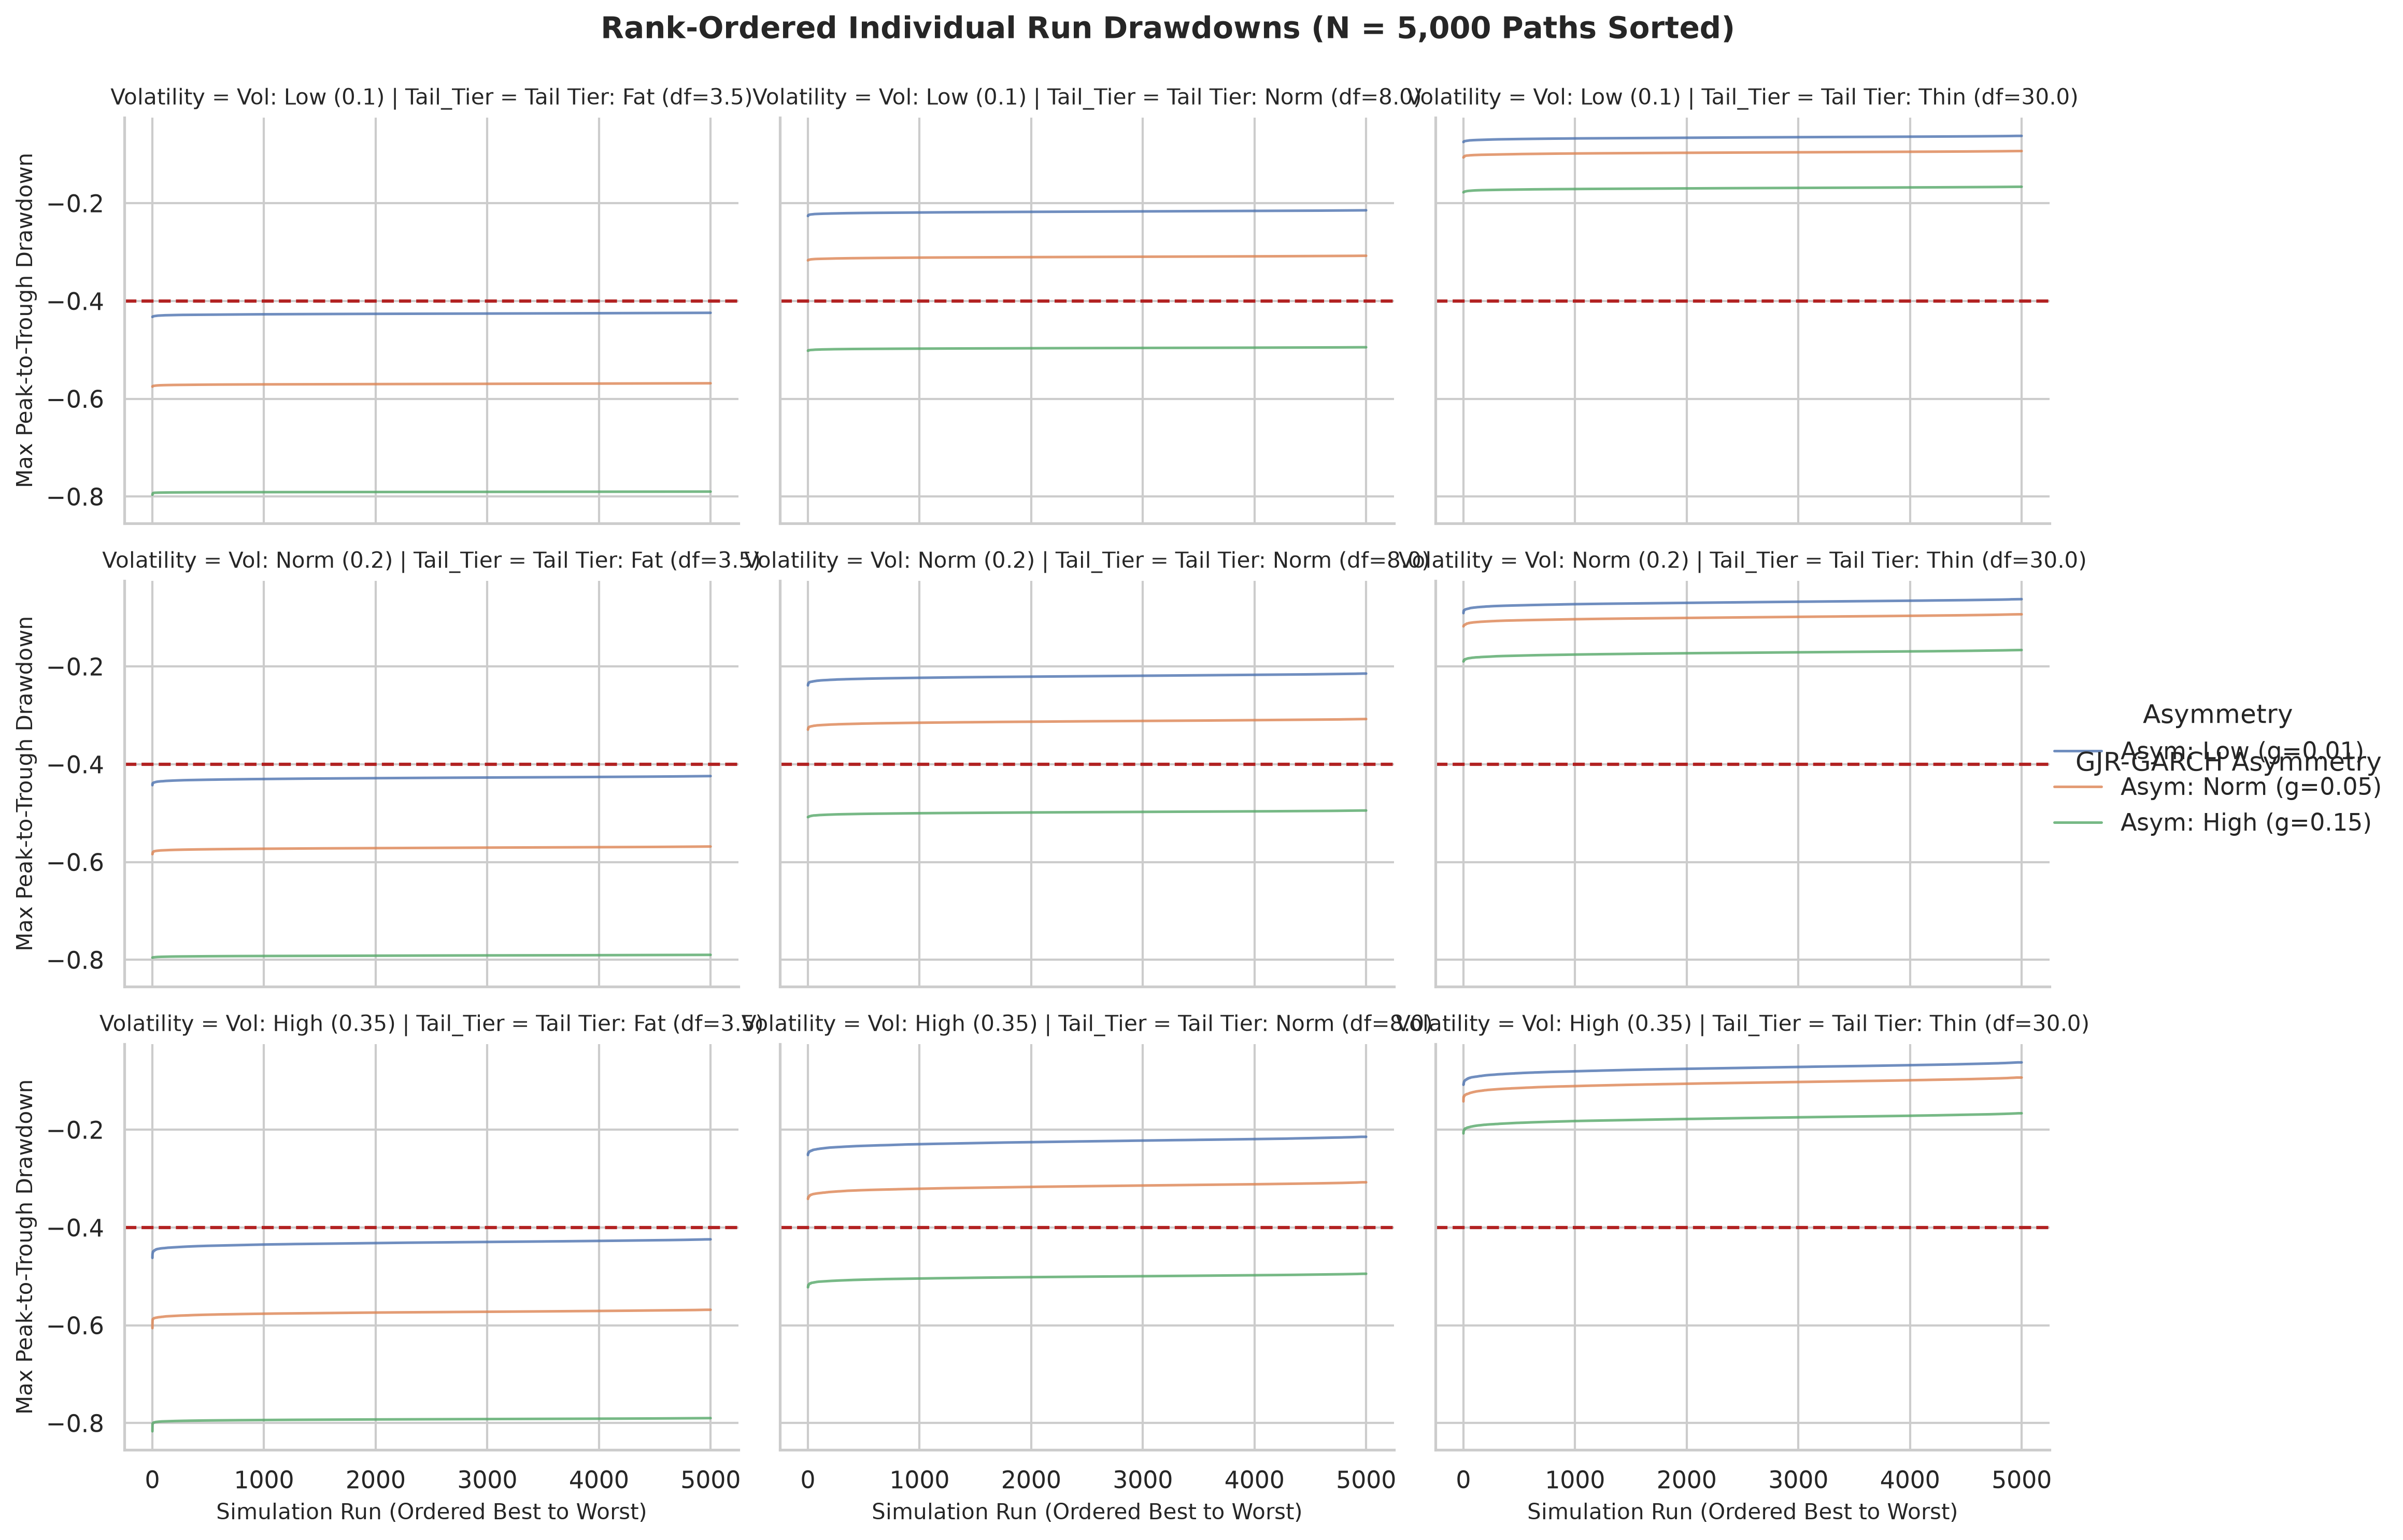

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
    }
)


def generate_ordered_drawdown_rank_plot() -> None:
    grid = generate_parameter_grid()
    records: list[dict[str, float | str]] = []

    print(
        "Extracting and sorting individual run drawdowns across all 27"
        " institutions (5,000 paths each)..."
    )
    for inst_name, profile in grid.items():
        _, max_drawdowns = run_shock_monte_carlo(profile, n_paths=5000, n_days=90)

        # Sort individual run max drawdowns from smallest (closest to 0) to largest drop
        sorted_dds = sorted(max_drawdowns)

        for rank, dd in enumerate(sorted_dds):
            records.append(
                {
                    "Rank": rank + 1,
                    "Max_Drawdown": dd,
                    "Institution": inst_name,
                    "Volatility": f"Vol: {profile['Vol_Tier']} ({profile['annual_vol']})",
                    "Tail_Tier": f"Tail Tier: {profile['Tail_Tier']} (df={profile['t_df']})",
                    "Asymmetry": f"Asym: {profile['Asym_Tier']} (g={profile['gjr_gamma']})",
                }
            )

    df_viz = pd.DataFrame(records)

    # Faceted line plot of ordered runs
    g = sns.relplot(
        data=df_viz,
        x="Rank",
        y="Max_Drawdown",
        hue="Asymmetry",
        col="Tail_Tier",
        row="Volatility",
        kind="line",
        alpha=0.8,
        linewidth=1.2,
        palette="deep",
        height=3.2,
        aspect=1.2,
        facet_kws={"sharey": True},
    )

    # Highlight the -40% distress threshold horizontally across all subplots
    for ax in g.axes.flat:
        ax.axhline(
            y=-0.40,
            color="firebrick",
            linestyle="--",
            linewidth=1.5,
            label="40% Distress Threshold",
        )
        ax.set_xlabel("Simulation Run (Ordered Best to Worst)")
        ax.set_ylabel("Max Peak-to-Trough Drawdown")

    g.add_legend(title="GJR-GARCH Asymmetry")
    g.fig.suptitle(
        "Rank-Ordered Individual Run Drawdowns (N = 5,000 Paths Sorted)",
        y=1.03,
        fontsize=14,
        fontweight="bold",
    )

    output_path = "../monte_carlo_ordered_drawdown_rank_grid.png"
    plt.savefig(output_path, bbox_inches="tight")
    print(f"Ordered rank drawdown grid successfully saved to '{output_path}'")
    plt.show()


generate_ordered_drawdown_rank_plot()

Simulating raw price and drawdown paths for the first 5 trials...
Path trace successfully saved to '../first_five_trials_path_trace.png'


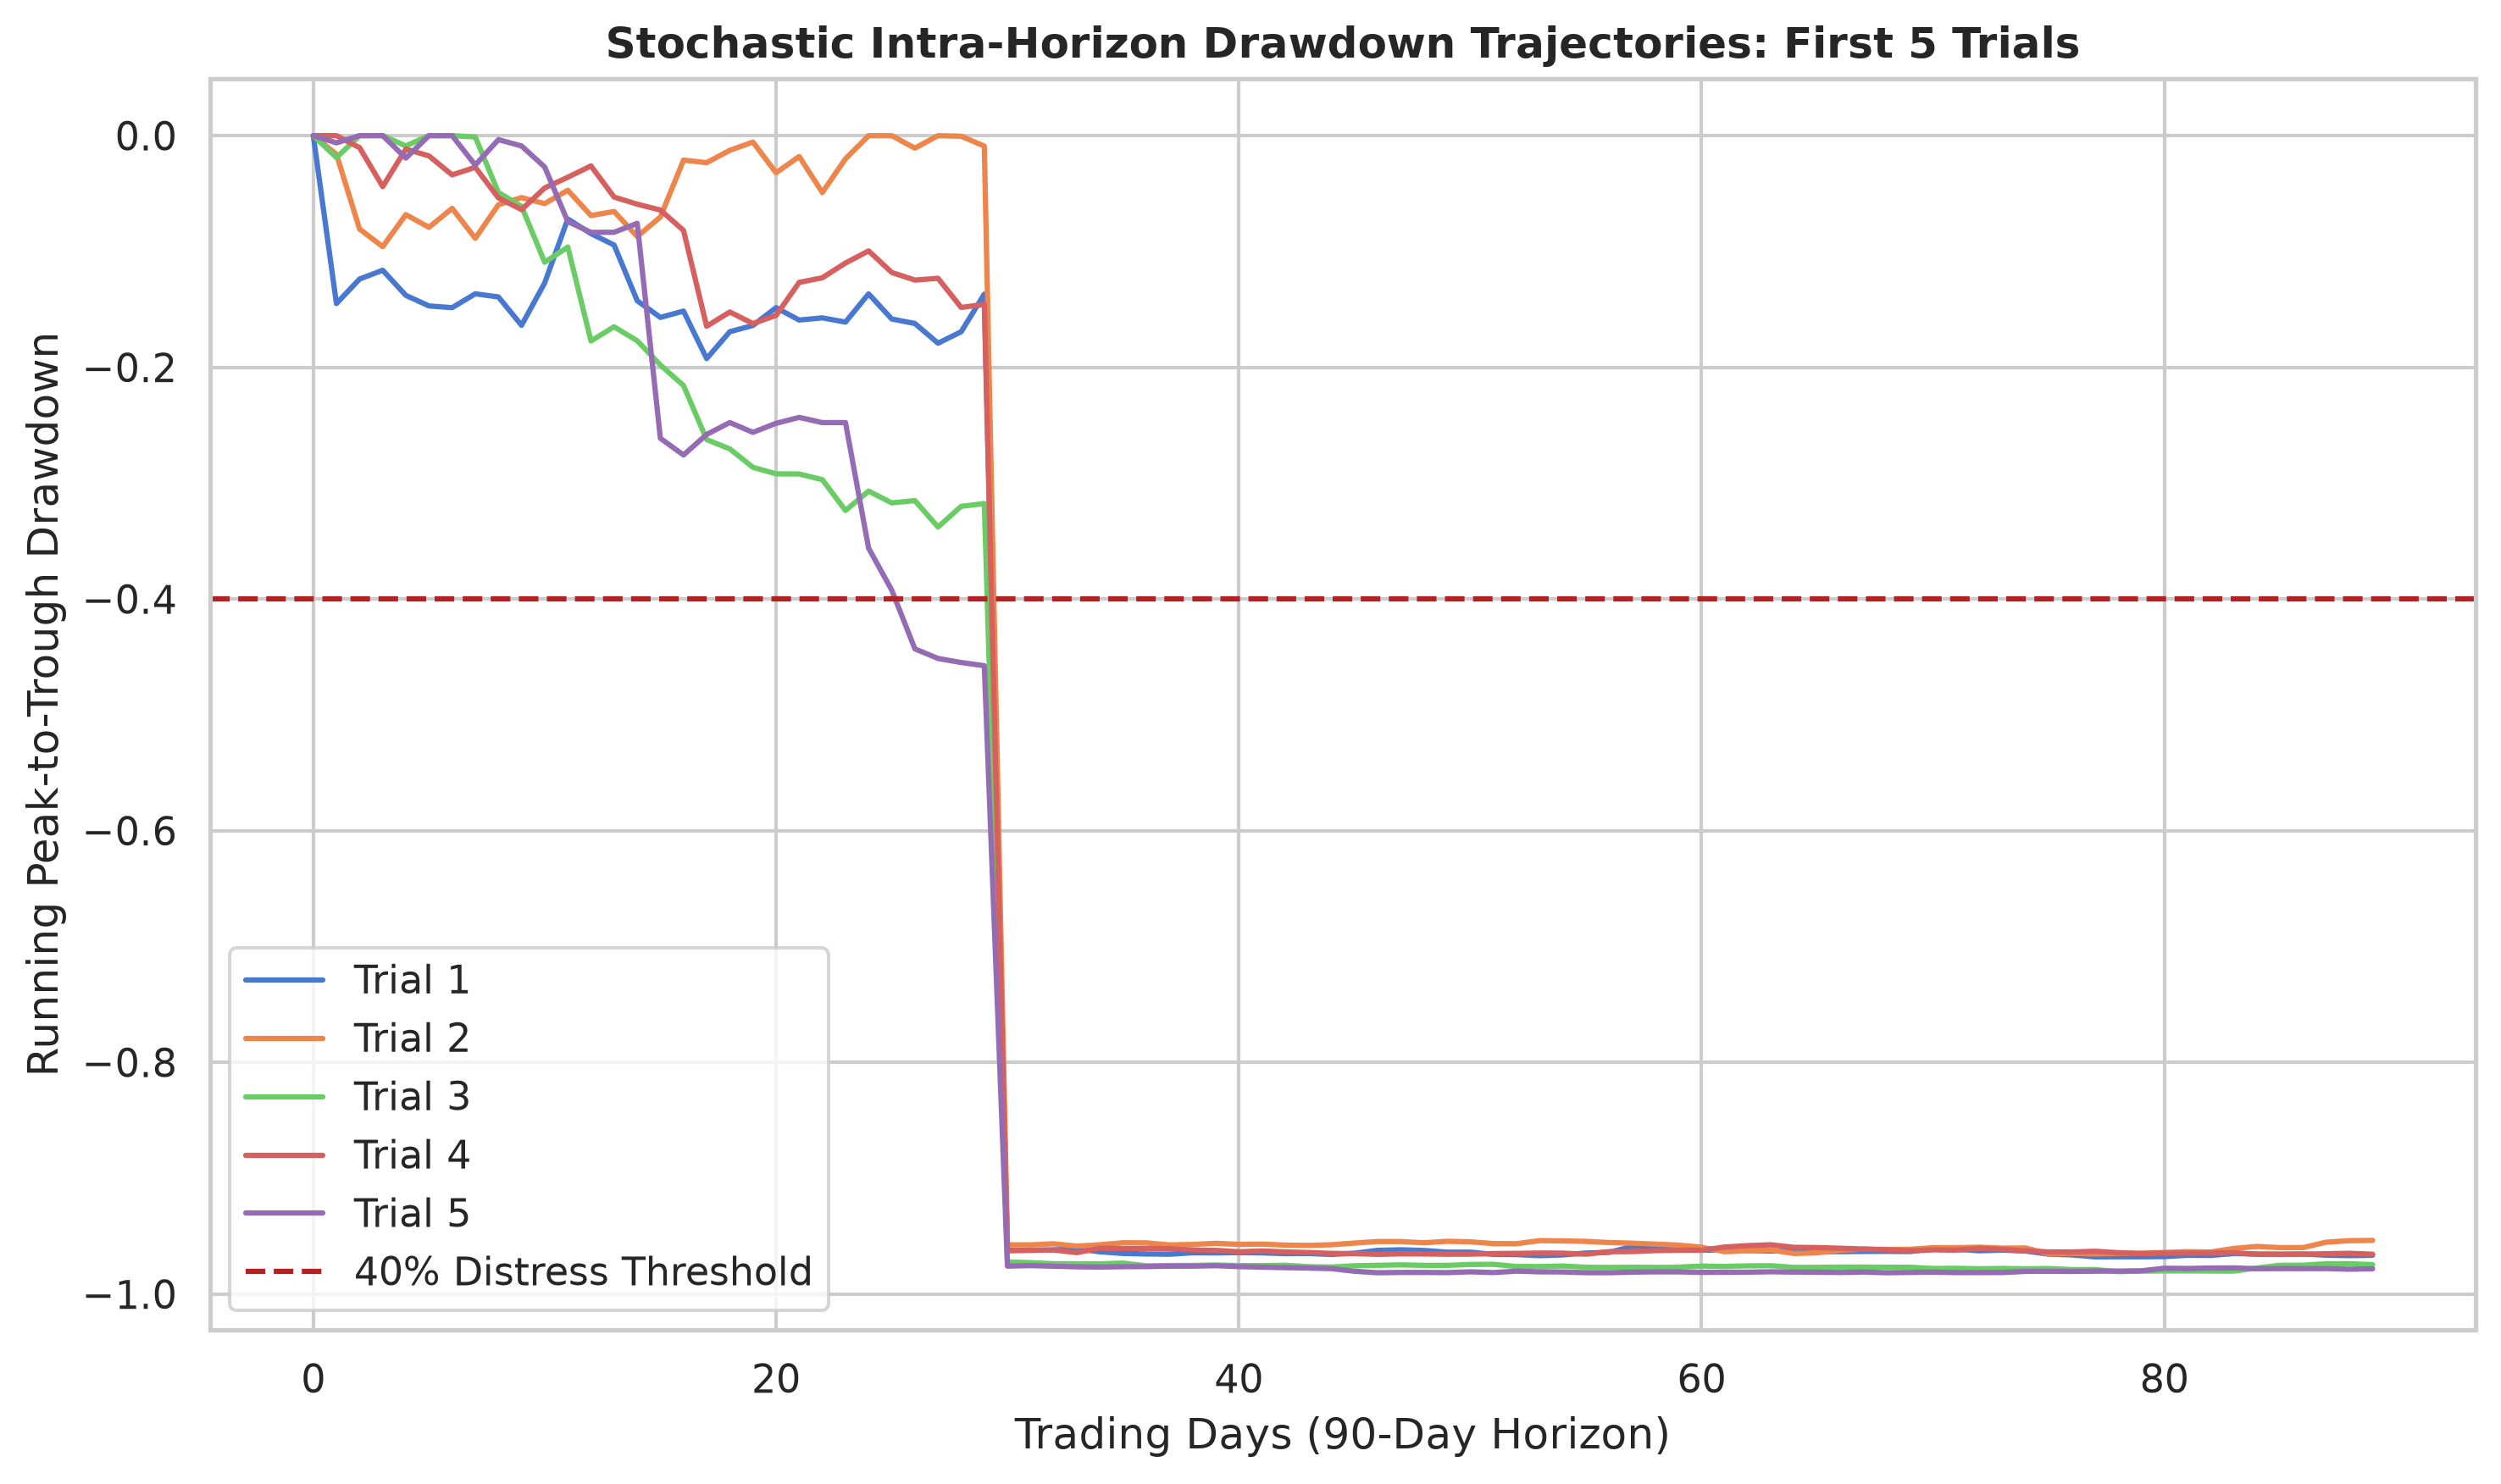

In [20]:
# check if stochastic process is working as expected by plotting the first 5 trials of a high-risk, fat-tailed node with a Day-30 shock

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")


def plot_first_five_trial_paths_direct() -> None:
    # Set parameters for a high-risk, fat-tailed node to test stochastic variance
    n_days = 90
    n_trials = 5
    dt = 1 / 252

    # Parameters (matching your high-risk grid profile)
    annual_vol = 0.35
    daily_vol = annual_vol / np.sqrt(252)
    t_df = 3.5  # Fat tail
    gjr_gamma = 0.15  # High asymmetry

    print("Simulating raw price and drawdown paths for the first 5 trials...")
    plt.figure(figsize=(10, 6))

    for i in range(n_trials):
        # Step 1: Generate random Student-t innovations (randomness lives here!)
        # Degrees of freedom = t_df
        random_innovations = np.random.standard_t(df=t_df, size=n_days)

        # Step 2: Construct daily returns with volatility scaling
        daily_returns = daily_vol * random_innovations

        # Step 3: Inject the Day-30 shock with asymmetry scaling
        shock_day = 30
        if shock_day < n_days:
            # Asymmetry amplifies the negative impact of the shock
            shock_magnitude = -0.42 * (1.0 + gjr_gamma * 15.0) * (8.0 / t_df)
            daily_returns[shock_day] += shock_magnitude

        # Step 4: Convert returns to a cumulative price path starting at 100
        price_path = 100 * np.exp(np.cumsum(daily_returns))

        # Step 5: Calculate running peak-to-trough drawdown path
        running_max = pd.Series(price_path).cummax()
        running_dd = (price_path - running_max) / running_max

        plt.plot(
            range(n_days),
            running_dd,
            linewidth=1.5,
            label=f"Trial {i+1}",
        )

    plt.axhline(
        y=-0.40,
        color="firebrick",
        linestyle="--",
        linewidth=1.5,
        label="40% Distress Threshold",
    )
    plt.title(
        "Stochastic Intra-Horizon Drawdown Trajectories: First 5 Trials",
        fontsize=12,
        fontweight="bold",
    )
    plt.xlabel("Trading Days (90-Day Horizon)")
    plt.ylabel("Running Peak-to-Trough Drawdown")
    plt.legend(loc="lower left")
    plt.tight_layout()

    output_path = "../first_five_trials_path_trace.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Path trace successfully saved to '{output_path}'")
    plt.show()


plot_first_five_trial_paths_direct()